In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [2]:
df = pd.read_csv("retail.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')

# Check missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [7]:

df_prophet = df[['Date', 'Sales']]
df_prophet.columns = ['ds', 'y']

In [8]:
df = df.dropna()

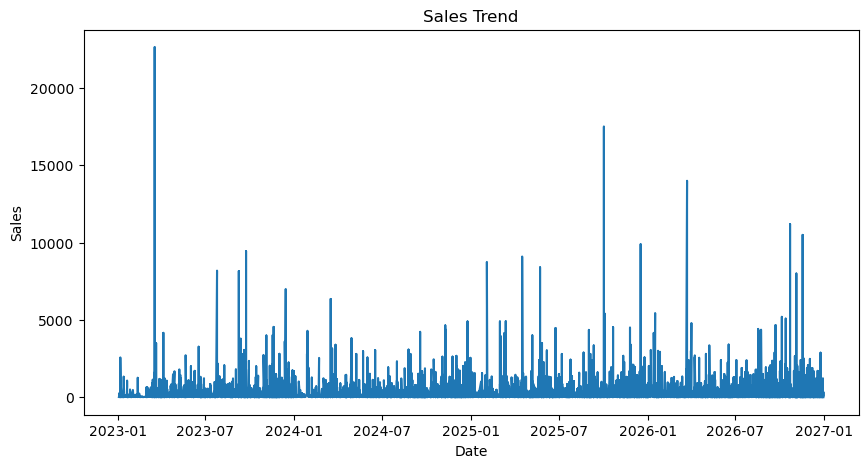

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'])
plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [10]:
df_prophet = df[['Date', 'Sales']]
df_prophet.columns = ['ds', 'y']
model = Prophet()  #train model 
model.fit(df_prophet)

22:51:22 - cmdstanpy - INFO - Chain [1] start processing
22:51:24 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
# future prediction
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-01-03,232.383499,-539.831306,1084.680952,232.383499,232.383499,-3.131877,-3.131877,-3.131877,2.207461,2.207461,2.207461,-5.339337,-5.339337,-5.339337,0.0,0.0,0.0,229.251622
1,2023-01-04,232.421275,-572.878751,952.988295,232.421275,232.421275,-19.581261,-19.581261,-19.581261,-10.868640,-10.868640,-10.868640,-8.712622,-8.712622,-8.712622,0.0,0.0,0.0,212.840014
2,2023-01-05,232.459051,-504.776250,1006.486725,232.459051,232.459051,-26.526085,-26.526085,-26.526085,-14.653153,-14.653153,-14.653153,-11.872932,-11.872932,-11.872932,0.0,0.0,0.0,205.932966
3,2023-01-06,232.496828,-592.529444,1015.827773,232.496828,232.496828,-28.311223,-28.311223,-28.311223,-13.585293,-13.585293,-13.585293,-14.725930,-14.725930,-14.725930,0.0,0.0,0.0,204.185605
4,2023-01-07,232.534604,-611.844107,962.722307,232.534604,232.534604,-0.738214,-0.738214,-0.738214,16.444636,16.444636,16.444636,-17.182851,-17.182851,-17.182851,0.0,0.0,0.0,231.796389


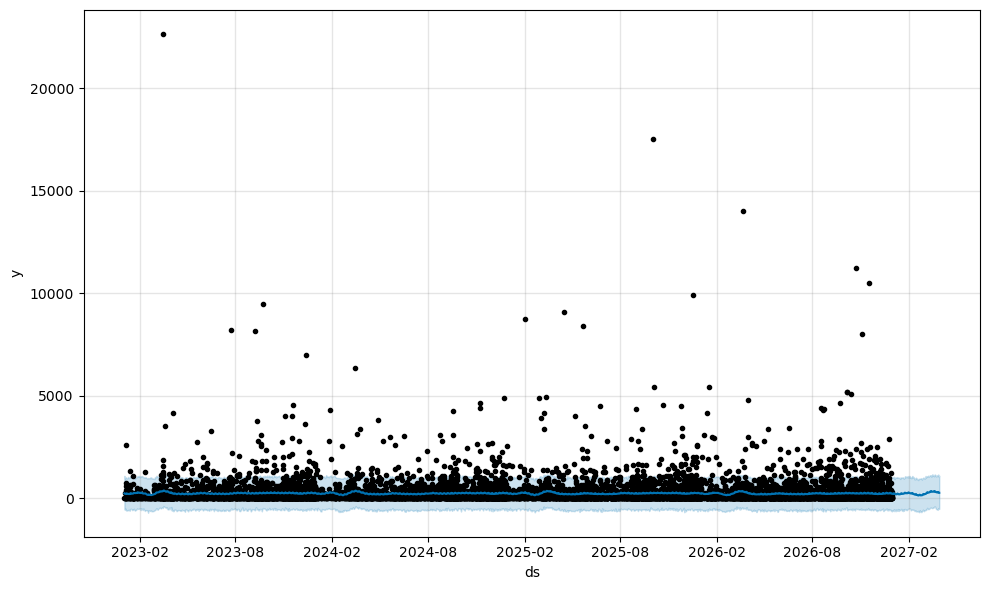

In [12]:
model.plot(forecast)
plt.show()


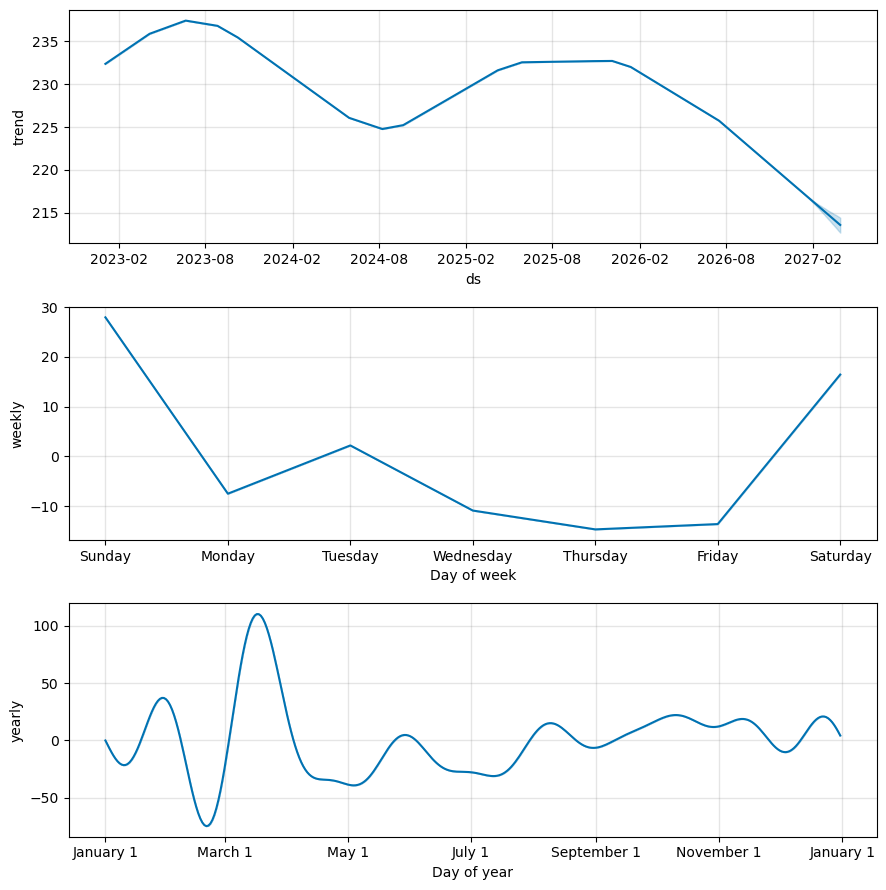

In [13]:
model.plot_components(forecast)
plt.show()

In [20]:
# /evaluation
# Step 1: Split
train = df_prophet[:-90]
test = df_prophet[-90:]

# Step 2: NEW model
model = Prophet()

# Step 3: Fit only once
model.fit(train)

# Step 4: Predict
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Step 5: Take last 90
pred = forecast[['ds', 'yhat']].tail(90)

# Step 6: Reset index
test = test.reset_index(drop=True)
pred = pred.reset_index(drop=True)

# Step 7: Evaluate
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test['y'], pred['yhat'])

print("MAE:", mae)


23:07:00 - cmdstanpy - INFO - Chain [1] start processing
23:07:01 - cmdstanpy - INFO - Chain [1] done processing


MAE: 220.43605299386314


In [21]:
model = Prophet()


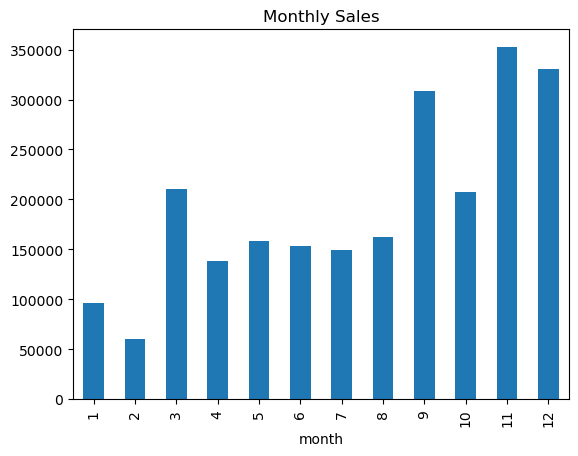

In [22]:
df['month'] = df['Date'].dt.month

monthly_sales = df.groupby('month')['Sales'].sum()

monthly_sales.plot(kind='bar', title="Monthly Sales")
plt.show()

In [23]:
print(f"Model MAE: {mae}")
print("This means predictions are off by approx this value on average.")

Model MAE: 220.43605299386314
This means predictions are off by approx this value on average.


C:\Users\admin\AppData\Local\Temp\ipykernel_11972\1223194074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prophet['Predicted'] = forecast['yhat'][:len(df)]


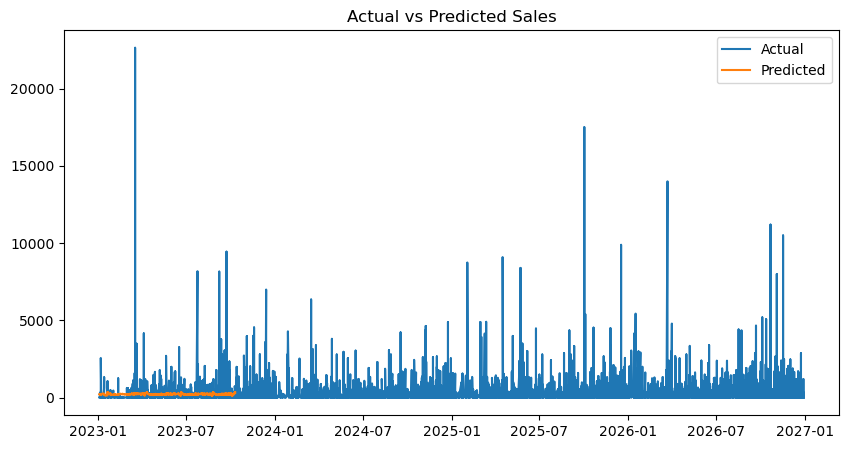

In [24]:
df_prophet['Predicted'] = forecast['yhat'][:len(df)]

plt.figure(figsize=(10,5))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual')
plt.plot(df_prophet['ds'], df_prophet['Predicted'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [ ]:
# Insights:
# 1. Sales show upward trend
# 2. Seasonal spikes observed
# 3. Model can help in inventory planning

In [25]:
forecast[['ds', 'yhat']].tail(10)

,ds,yhat
1315,2027-03-14,350.132925
1316,2027-03-15,321.372817
1317,2027-03-16,332.024848
1318,2027-03-17,321.600865
1319,2027-03-18,316.303299
1320,2027-03-19,319.387682
1321,2027-03-20,346.663455
1322,2027-03-21,355.173847
1323,2027-03-22,317.474019
1324,2027-03-23,319.507516


In [26]:
import pickle

with open("sales_model.pkl", "wb") as f:
    pickle.dump(model, f)